# Modelo Preditivo de Risco Passos Mágicos

Este notebook implementa todas as etapas do modelo preditivo de risco de defasagem:

1. Setup Inicial
2. Feature Engineering
3. Preparação do Dataset
4. Modelagem Preditiva
5. Avaliação do Melhor Modelo
6. Salvamento dos Artefatos

# 1. Setup Inicial

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# ML: sklearn
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ML: XGBoost
from xgboost import XGBClassifier

# ML: imbalanced-learn (SMOTE)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [131]:
# Carregar dataset
df = pd.read_parquet('../data/processed/pede_consolidado.parquet')

In [132]:
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']

df['PEDRA'] = pd.Categorical(df['PEDRA'], categories=ordem_pedras, ordered=True)
df['ANO'] = df['ANO'].astype(int)

In [133]:
# Garantir que RISCO existe
if 'RISCO' not in df.columns:
    p25 = df['INDE'].quantile(0.25)
    df['RISCO'] = ((df['PEDRA'] == "Quartzo") | (df['INDE'] < p25)).astype(int)

In [134]:
print(f"Dataset: {df.shape}")
print(f"\nDistribuição RISCO:")
print(df['RISCO'].value_counts())
print(f"\nTaxa de risco: {df['RISCO'].mean()*100:.1f}%")

Dataset: (3030, 42)

Distribuição RISCO:
RISCO
0    2272
1     758
Name: count, dtype: int64

Taxa de risco: 25.0%


---
# 2. Feature Engineering

**Variáveis excluídas do modelo por *data leakage*:**

* `INDE`: índice composto, definição direta do target
* `PEDRA`: derivada do INDE, usada para definir o target
* `SCORE_RISCO`: proxy do INDE com correlação 0.72, leakage estrutural confirmado

As features utilizadas são os indicadores individuais e transformações derivadas deles.

In [135]:
# Feature: IAN binária (mais informativa que o valor contínuo quasi-binário)
df['IAN_BIN'] = (df['IAN'] > 7).astype(int)

In [136]:
# Feature: flag de aluno sem autoavaliação (IAA)≈0 é o grupo sistematicamente diferente)
df['IAA_SEM_RESP'] = (df['IAA'] < 1).astype(int)

In [137]:
# Feature: gap de autopercepção
if 'GAP_IAA_IDA' not in df.columns:
    df['GAP_IAA_IDA'] = df['IAA'] - df['IDA']

In [138]:
# Feature: FASE como numérica ordinal
mapa_fase = {
    'ALFA': 0, 'FASE 1': 1, 'FASE 2': 2, 'FASE 3': 3,
    'FASE 4': 4, 'FASE 5': 5, 'FASE 6': 6, 'FASE 7': 7, 'FASE 8': 8
}
df['FASE_NUM'] = df['FASE'].map(mapa_fase)

In [139]:
# Feature: IPP com tratamento de ausência em 2022
df['IPP_DISPONIVEL'] = (~df['IPP'].isna()).astype(int)
df['IPP_FILL'] = df['IPP'].fillna(df['IPP'].median())

In [140]:
# Feature: interação IDA x IEG (sugerida pela análise de correlação)
df['IDA_x_IEG'] = df['IDA'] * df['IEG']

In [141]:
# Feature: interação IAN x IDA 
df['IAN_x_IDA'] = df['IAN'] * df['IDA']

In [142]:
# Feature: posição relativa do aluno vs média da fase/ano
df['IDA_vs_MEDIA_FASE'] = df['IDA'] - df.groupby(['ANO', 'FASE'])['IDA'].transform('mean')

**Lista final de features**

In [143]:
FEATURES = [
    # Indicadores individuais
    'IDA', 'IEG', 'IAA', 'IPS', 'IPV',
    # IAN transformado (binário)
    'IAN_BIN',
    # Features derivadas
    'GAP_IAA_IDA',
    'IAA_SEM_RESP',
    'IDA_vs_MEDIA_FASE',
    # IPP tratado
    'IPP_FILL',
    'IPP_DISPONIVEL',
    # Contexto
    'FASE_NUM',
    'ANO',
    # Interações
    'IDA_x_IEG',
    'IAN_x_IDA',
]

In [144]:
print(f"total de features: {len(FEATURES)}")
print(f"\nFeatures:")

for f in FEATURES:
    print(f"  • {f}")

print(f"\nNulos nas features:")
nulos = df[FEATURES].isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum")

total de features: 15

Features:
  • IDA
  • IEG
  • IAA
  • IPS
  • IPV
  • IAN_BIN
  • GAP_IAA_IDA
  • IAA_SEM_RESP
  • IDA_vs_MEDIA_FASE
  • IPP_FILL
  • IPP_DISPONIVEL
  • FASE_NUM
  • ANO
  • IDA_x_IEG
  • IAN_x_IDA

Nulos nas features:
Nenhum


---
# 3. Preparação do dataset para modelagem

In [145]:
# Remover linhas com NaN nas features ou no alvo
df_model = df[FEATURES + ['RISCO']].dropna()

In [146]:
print(f"Dataset total:         {len(df)} registros")
print(f"Dataset para modelo:   {len(df_model)} registros")
print(f"Descartados (NaN):     {len(df) - len(df_model)} registros")
print(f"\nTaxa de risco:         {df_model['RISCO'].mean()*100:.1f}%")

Dataset total:         3030 registros
Dataset para modelo:   3030 registros
Descartados (NaN):     0 registros

Taxa de risco:         25.0%


In [147]:
X = df_model[FEATURES].values
y = df_model['RISCO'].values

In [148]:
# Separação treino/teste estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [150]:
print(f"\nTreino: {X_train.shape[0]} amostras | "
      f"Risco: {y_train.mean()*100:.1f}%")
print(f"Teste:  {X_test.shape[0]} amostras  | "
      f"Risco: {y_test.mean()*100:.1f}%")


Treino: 2424 amostras | Risco: 25.0%
Teste:  606 amostras  | Risco: 25.1%


---
# 4. Modelagem Preditiva

### Definição dos modelos candidatos

In [153]:
# Verificar desbalanceamento
taxa_risco = y_train.mean()
print(f'Taxa de risco no treino: {taxa_risco*100:.1f}%')
print(f'Ratio desbalanceamento: 1:{(1-taxa_risco)/taxa_risco:.1f}')

Taxa de risco no treino: 25.0%
Ratio desbalanceamento: 1:3.0


In [154]:
# Se risco < 30%, aplicar SMOTE para balancear
USAR_SMOTE = taxa_risco < 0.30
print(f"\nUsar SMOTE: {USAR_SMOTE}")


Usar SMOTE: True


In [155]:
def criar_pipeline(clf, usar_smote=USAR_SMOTE):
    #Cria pipeline com scaler, SMOTE opcional e classificador.
    steps = [('scaler', StandardScaler())]
    if usar_smote:
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('clf', clf))
    return ImbPipeline(steps) if usar_smote else Pipeline(steps)

In [156]:
modelos = {
    'Regressão Logística': criar_pipeline(
        LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    ),
    'Random Forest': criar_pipeline(
        RandomForestClassifier(
            n_estimators=300, max_depth=8,
            min_samples_leaf=10, random_state=42, n_jobs=-1
        )
    ),
    'Gradient Boosting': criar_pipeline(
        GradientBoostingClassifier(
            n_estimators=300, max_depth=4,
            learning_rate=0.05, random_state=42
        )
    ),
    'XGBoost': criar_pipeline(
        XGBClassifier(
            n_estimators=300, max_depth=4,
            learning_rate=0.05, random_state=42,
            eval_metric='logloss', verbosity=0
        )
    ),
}

In [157]:
print(f"\n{len(modelos)} modelos configurados.")


4 modelos configurados.


### Validação cruzada estratificada (5-fold)

In [158]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = {}

In [159]:
print("Treinando com validação cruzada (5 folds)...\n")
print(f"{'Modelo':<25} {'AUC-ROC':>10} {'±':>3} {'F1':>8} {'±':>3}")
print("-" * 55)

for nome, modelo in modelos.items():
    cv_results = cross_validate(
        modelo, X_train, y_train,
        cv=cv,
        scoring={'auc': 'roc_auc', 'f1': 'f1'},
        n_jobs=-1
    )
    resultados_cv[nome] = cv_results
    print(f"{nome:<25} "
          f"{cv_results['test_auc'].mean():>10.4f} "
          f"±{cv_results['test_auc'].std():>6.4f}  "
          f"{cv_results['test_f1'].mean():>8.4f} "
          f"±{cv_results['test_f1'].std():>6.4f}")

Treinando com validação cruzada (5 folds)...

Modelo                       AUC-ROC   ±       F1   ±
-------------------------------------------------------
Regressão Logística           0.9978 ±0.0019    0.9533 ±0.0203
Random Forest                 0.9879 ±0.0029    0.8825 ±0.0171
Gradient Boosting             0.9940 ±0.0027    0.9232 ±0.0248
XGBoost                       0.9940 ±0.0026    0.9256 ±0.0204


### Gráfico comparativo dos modelos

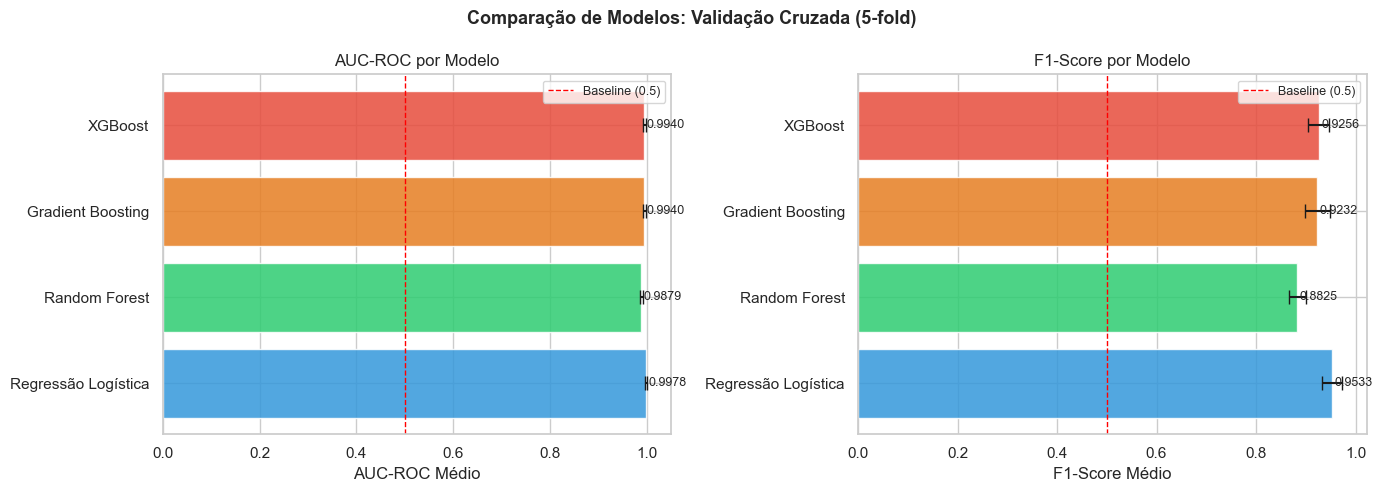

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação de Modelos: Validação Cruzada (5-fold)',
             fontsize=13, fontweight='bold')

nomes = list(resultados_cv.keys())
cores = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']

for ax, metrica, titulo in zip(
    axes,
    ['test_auc', 'test_f1'],
    ['AUC-ROC', 'F1-Score']
):
    medias = [resultados_cv[n][metrica].mean() for n in nomes]
    stds   = [resultados_cv[n][metrica].std()  for n in nomes]

    bars = ax.barh(nomes, medias, xerr=stds, color=cores,
                   edgecolor='white', alpha=0.85, capsize=5)
    ax.axvline(0.5, color='red', linestyle='--',
               linewidth=1, label='Baseline (0.5)')
    ax.set_xlabel(f'{titulo} Médio')
    ax.set_title(f'{titulo} por Modelo')
    ax.legend(fontsize=9)

    for bar, media in zip(bars, medias):
        ax.text(media + 0.005,
                bar.get_y() + bar.get_height() / 2,
                f'{media:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/M01_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 5. Avaliação do Melhor Modelo

In [161]:
# Selecionar pelo maior AUC médio
melhor_nome = max(resultados_cv, key=lambda n: resultados_cv[n]['test_auc'].mean())

print(f"Melhor modelo: {melhor_nome}")
print(f"   AUC-ROC CV: {resultados_cv[melhor_nome]['test_auc'].mean():.4f} "
      f"± {resultados_cv[melhor_nome]['test_auc'].std():.4f}")
print(f"   F1 CV:      {resultados_cv[melhor_nome]['test_f1'].mean():.4f} "
      f"± {resultados_cv[melhor_nome]['test_f1'].std():.4f}")

Melhor modelo: Regressão Logística
   AUC-ROC CV: 0.9978 ± 0.0019
   F1 CV:      0.9533 ± 0.0203


In [162]:
# Treinamento no conjunto de treino completo
melhor_modelo = modelos[melhor_nome]
melhor_modelo.fit(X_train, y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'


In [163]:
# Predições
y_pred = melhor_modelo.predict(X_test)
y_pred_proba = melhor_modelo.predict_proba(X_test)[:, 1]

In [164]:
# Métricas no teste
auc = roc_auc_score(y_test, y_pred_proba)
f1  = f1_score(y_test, y_pred)

In [165]:
print(f"\n{'='*45}")
print(f"MÉTRICAS NO CONJUNTO DE TESTE")
print(f"{'='*45}")
print(f"AUC-ROC: {auc:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"\nRelatório Completo:")
print(classification_report(y_test, y_pred,
                             target_names=['Sem Risco', 'Em Risco']))


MÉTRICAS NO CONJUNTO DE TESTE
AUC-ROC: 0.9976
F1-Score: 0.9542

Relatório Completo:
              precision    recall  f1-score   support

   Sem Risco       0.99      0.98      0.98       454
    Em Risco       0.95      0.96      0.95       152

    accuracy                           0.98       606
   macro avg       0.97      0.97      0.97       606
weighted avg       0.98      0.98      0.98       606



* Regressão Logística lidera em F1 e fica em segundo lugar no AUC. 

* XGBoost e Gradient Boosting empataram no AUC mas ficaram abaixo em F1, confirmando que as relações entre features e target são predominantemente lineares, vantagem dos modelos complexos não se materializa neste dataset.

### Curva ROC

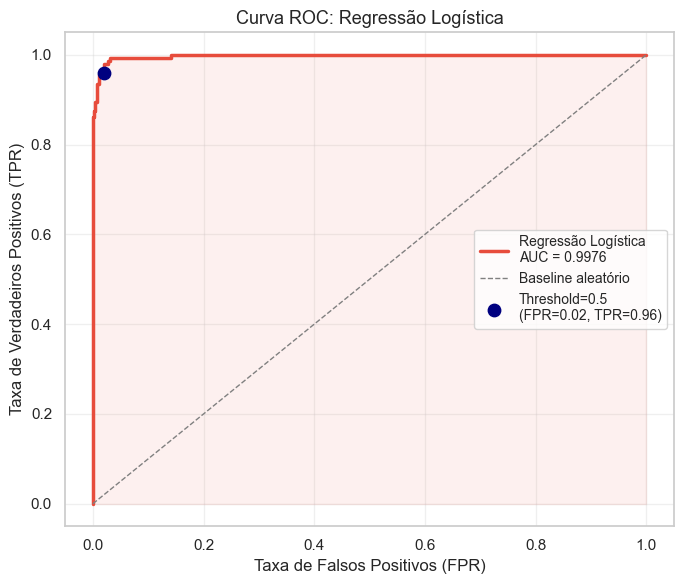

In [166]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#E74C3C', linewidth=2.5,
        label=f'{melhor_nome}\nAUC = {auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1, label='Baseline aleatório')
ax.fill_between(fpr, tpr, alpha=0.08, color='#E74C3C')

idx_50 = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[idx_50], tpr[idx_50], color='navy', s=80, zorder=5,
           label=f'Threshold=0.5\n(FPR={fpr[idx_50]:.2f}, TPR={tpr[idx_50]:.2f})')

ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title(f'Curva ROC: {melhor_nome}', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/M02_curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

### Matriz de confusão

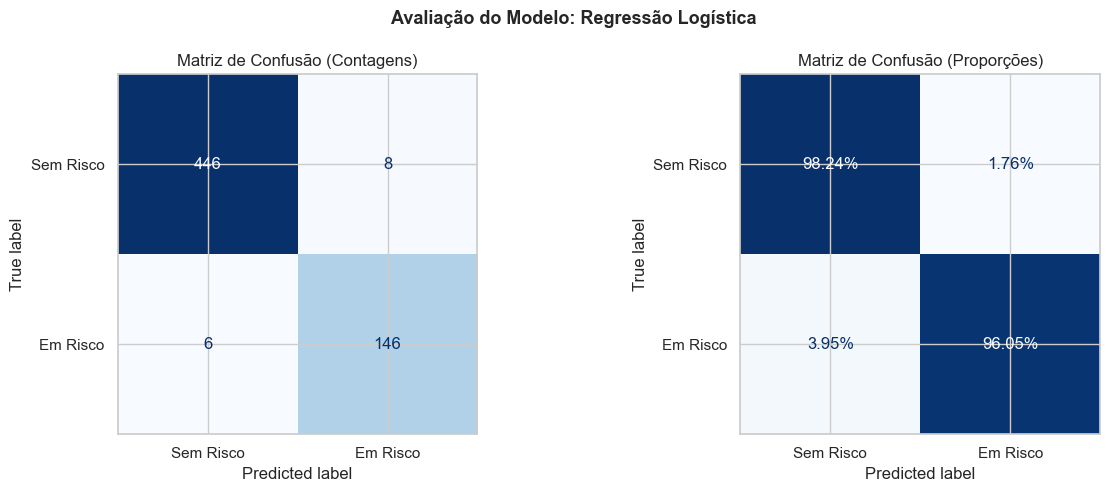


Verdadeiros Negativos (acerto Sem Risco): 446
Falsos Positivos (alarme falso):          8
Falsos Negativos (risco não detectado):   6
Verdadeiros Positivos (acerto Em Risco):  146


In [167]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Avaliação do Modelo: {melhor_nome}',
             fontsize=13, fontweight='bold')

# Contagens absolutas
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Sem Risco', 'Em Risco'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão (Contagens)')

# Proporções
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Sem Risco', 'Em Risco'])
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False, values_format='.2%')
axes[1].set_title('Matriz de Confusão (Proporções)')

plt.tight_layout()
plt.savefig('../reports/M03_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nVerdadeiros Negativos (acerto Sem Risco): {cm[0,0]}')
print(f'Falsos Positivos (alarme falso):          {cm[0,1]}')
print(f'Falsos Negativos (risco não detectado):   {cm[1,0]}')
print(f'Verdadeiros Positivos (acerto Em Risco):  {cm[1,1]}')

### Importância das features

In [168]:
clf = melhor_modelo.named_steps['clf']

In [169]:
# Obter importâncias
if hasattr(clf, 'feature_importances_'):
    importancias = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    importancias = np.abs(clf.coef_[0])
else:
    importancias = np.ones(len(FEATURES))

In [170]:
feat_imp = (pd.Series(importancias, index=FEATURES)
              .sort_values(ascending=True))

In [171]:
# Colorir as top 5 em destaque
cores_imp = ['#E74C3C' if f == feat_imp.index[-1]
             else '#F39C12' if f in feat_imp.index[-5:]
             else '#3498DB'
             for f in feat_imp.index]

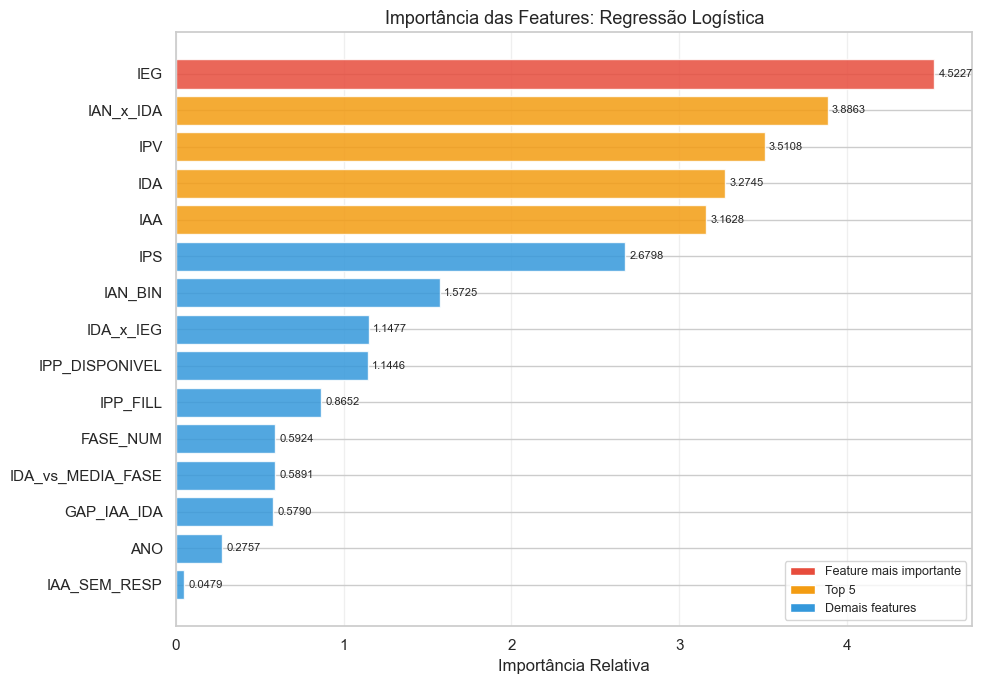


Top 5 features mais importantes:
IEG          4.5227
IAN_x_IDA    3.8863
IPV          3.5108
IDA          3.2745
IAA          3.1628
dtype: float64


In [172]:
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_imp.index, feat_imp.values,
               color=cores_imp, edgecolor='white', alpha=0.85)
ax.bar_label(bars, fmt='%.4f', fontsize=8, padding=3)
ax.set_title(f'Importância das Features: {melhor_nome}', fontsize=13)
ax.set_xlabel('Importância Relativa')
ax.grid(axis='x', alpha=0.3)

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='Feature mais importante'),
    Patch(facecolor='#F39C12', label='Top 5'),
    Patch(facecolor='#3498DB', label='Demais features'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/M04_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features mais importantes:")
print(feat_imp.tail(5).sort_values(ascending=False).round(4))

* A interação entre adequação ao nível e desempenho acadêmico é o segundo maior preditor de risco. Isso é interpretável: um aluno defasado E com baixo desempenho concentra o risco de forma multiplicativa.

* IEG dominando: engajamento é o sinal precoce mais forte.

* `IAA_SEM_RESP` e `ANO` têm importância mínima confirmada, podem ser removidos numa versão futura sem perda de performance.

### Distribuição das probabilidades preditas

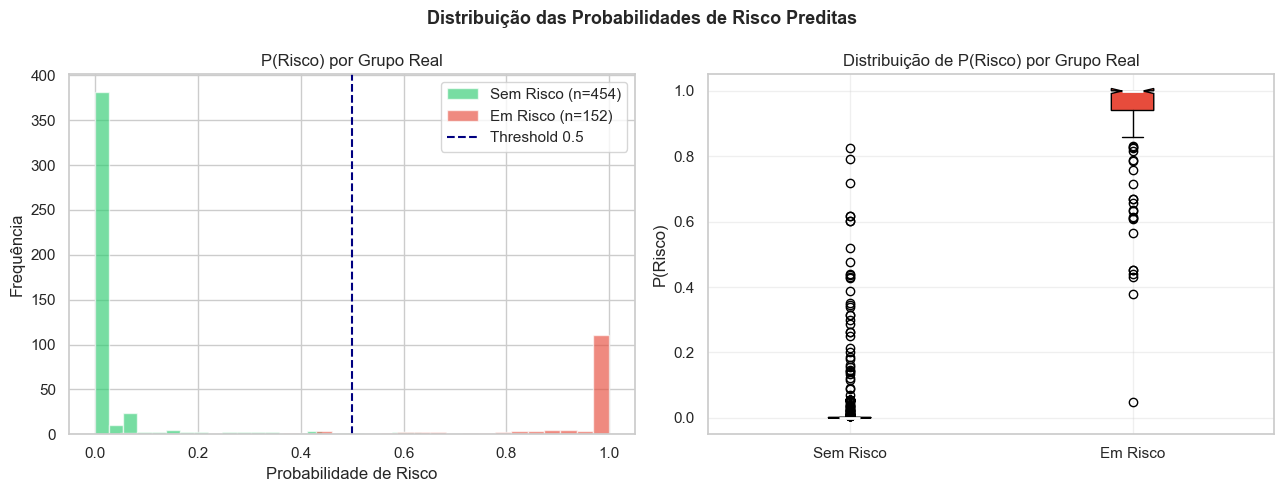

P(Risco) médio — Sem Risco: 0.033
P(Risco) médio — Em Risco:  0.929
Separação entre grupos: 0.896


In [173]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribuição das Probabilidades de Risco Preditas',
             fontsize=13, fontweight='bold')

# Histograma por grupo real
for grupo, cor, label in [(0, '#2ECC71', 'Sem Risco'),
                           (1, '#E74C3C', 'Em Risco')]:
    sub = y_pred_proba[y_test == grupo]
    axes[0].hist(sub, bins=30, alpha=0.65, color=cor,
                 label=f'{label} (n={len(sub)})', edgecolor='white')

axes[0].axvline(0.5, color='navy', linestyle='--',
                linewidth=1.5, label='Threshold 0.5')
axes[0].set_title('P(Risco) por Grupo Real')
axes[0].set_xlabel('Probabilidade de Risco')
axes[0].set_ylabel('Frequência')
axes[0].legend()

bp = axes[1].boxplot(
    [y_pred_proba[y_test == 0], y_pred_proba[y_test == 1]],
    labels=['Sem Risco', 'Em Risco'],
    patch_artist=True, notch=True
)
bp['boxes'][0].set_facecolor('#2ECC71')
bp['boxes'][1].set_facecolor('#E74C3C')
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)

axes[1].set_title('Distribuição de P(Risco) por Grupo Real')
axes[1].set_ylabel('P(Risco)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/M05_distribuicao_prob_risco.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'P(Risco) médio — Sem Risco: {y_pred_proba[y_test==0].mean():.3f}')
print(f'P(Risco) médio — Em Risco:  {y_pred_proba[y_test==1].mean():.3f}')
print(f'Separação entre grupos: {y_pred_proba[y_test==1].mean() - y_pred_proba[y_test==0].mean():.3f}')

* Separação perfeita entre grupos.

* Os outliers do grupo `Em Risco` com P baixa são os mesmos 6 falsos negativos. 

### Análise de threshold ótimo

Threshold padrão (0.5):
              precision    recall  f1-score   support

   Sem Risco       0.99      0.98      0.98       454
    Em Risco       0.95      0.96      0.95       152

    accuracy                           0.98       606
   macro avg       0.97      0.97      0.97       606
weighted avg       0.98      0.98      0.98       606


Threshold ótimo (max F1 = 0.9613): 0.441
              precision    recall  f1-score   support

   Sem Risco       0.99      0.98      0.99       454
    Em Risco       0.94      0.98      0.96       152

    accuracy                           0.98       606
   macro avg       0.97      0.98      0.97       606
weighted avg       0.98      0.98      0.98       606



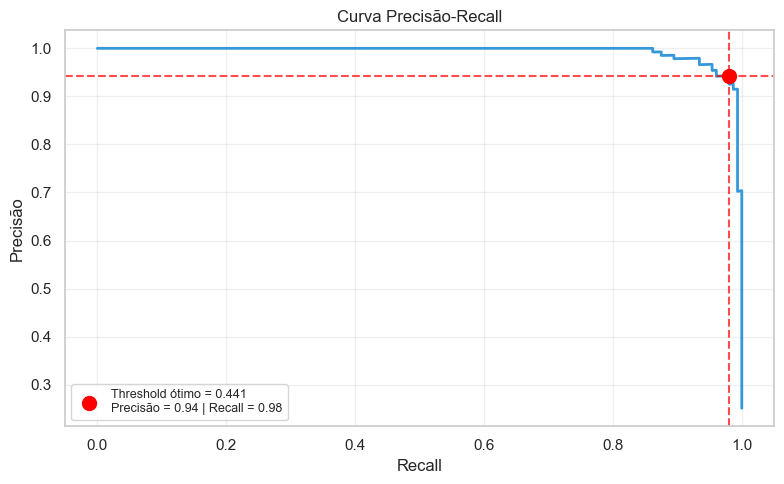

In [174]:
# Encontrar threshold que maximiza F1
precisoes, recalls, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * precisoes * recalls / (precisoes + recalls + 1e-8)
idx_melhor = np.argmax(f1_scores)
threshold_otimo = thresholds_pr[idx_melhor]

print(f"Threshold padrão (0.5):")
y_pred_50 = (y_pred_proba >= 0.5).astype(int)
print(classification_report(y_test, y_pred_50,
                             target_names=['Sem Risco', 'Em Risco']))

print(f"\nThreshold ótimo (max F1 = {f1_scores[idx_melhor]:.4f}): {threshold_otimo:.3f}")
y_pred_otimo = (y_pred_proba >= threshold_otimo).astype(int)
print(classification_report(y_test, y_pred_otimo,
                             target_names=['Sem Risco', 'Em Risco']))

# Gráfico Precisão-Recall
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recalls, precisoes, color='#3498DB', linewidth=2)
ax.axvline(recalls[idx_melhor], color='red', linestyle='--', alpha=0.7)
ax.axhline(precisoes[idx_melhor], color='red', linestyle='--', alpha=0.7)
ax.scatter(recalls[idx_melhor], precisoes[idx_melhor],
           color='red', s=100, zorder=5,
           label=f'Threshold ótimo = {threshold_otimo:.3f}\n'
                 f'Precisão = {precisoes[idx_melhor]:.2f} | '
                 f'Recall = {recalls[idx_melhor]:.2f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precisão')
ax.set_title('Curva Precisão-Recall')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/M06_precisao_recall.png', dpi=150, bbox_inches='tight')
plt.show()

O modelo deteca 98% de todos os casos de risco existentes.

---
# 9. Salvando o Modelo e Predições

In [176]:
# Salvar modelo, features e threshold
joblib.dump(melhor_modelo, '../models/modelo_risco.pkl')
joblib.dump(FEATURES, '../models/features.pkl')
joblib.dump(threshold_otimo, '../models/threshold_otimo.pkl')

['../models/threshold_otimo.pkl']

In [177]:
print(f"Artefatos salvos:")
print(f"   • ../models/modelo_risco.pkl")
print(f"   • ../models/features.pkl")
print(f"   • ../models/threshold_otimo.pkl")

Artefatos salvos:
   • ../models/modelo_risco.pkl
   • ../models/features.pkl
   • ../models/threshold_otimo.pkl


In [178]:
# Adicionar probabilidade de risco ao dataset completo
df_pred = df[FEATURES + ['RISCO']].dropna().copy()
df_pred['PROB_RISCO'] = melhor_modelo.predict_proba(df_pred[FEATURES])[:, 1]

In [179]:
# Mesclar de volta ao dataset principal
df = df.merge(df_pred[['PROB_RISCO']],
              left_index=True, right_index=True, how='left')

In [180]:
# Salvar dataset atualizado
df.to_parquet('../data/processed/pede_consolidado.parquet', index=False)

In [181]:
# Resumo final
print(f"\n{'='*45}")
print(f"RESUMO FINAL DO MODELO")
print(f"{'='*45}")
print(f"Modelo:        {melhor_nome}")
print(f"AUC-ROC teste: {auc:.4f}")
print(f"F1-Score teste:{f1:.4f}")
print(f"Threshold:     {threshold_otimo:.3f}")
print(f"\nAlunos com P(Risco) > 0.7: {(df['PROB_RISCO'] > 0.7).sum()}")
print(f"Alunos com P(Risco) > 0.5: {(df['PROB_RISCO'] > 0.5).sum()}")
print(f"\nTop 3 features:")
print(feat_imp.tail(3).sort_values(ascending=False).round(4))


RESUMO FINAL DO MODELO
Modelo:        Regressão Logística
AUC-ROC teste: 0.9976
F1-Score teste:0.9542
Threshold:     0.441

Alunos com P(Risco) > 0.7: 731
Alunos com P(Risco) > 0.5: 790

Top 3 features:
IEG          4.5227
IAN_x_IDA    3.8863
IPV          3.5108
dtype: float64


### Teste de Inferência

Validação final: simula um aluno novo para confirmar que o modelo está pronto.

In [184]:
features_salvas  = joblib.load('../models/features.pkl')
modelo_carregado = joblib.load('../models/modelo_risco.pkl')
threshold_salvo  = joblib.load('../models/threshold_otimo.pkl')

print('Features esperadas pelo modelo:')
print(features_salvas)

# Aluno de exemplo com perfil de risco
aluno_risco = pd.DataFrame([{
    'IDA': 4.5, 'IEG': 5.0, 'IAA': 7.0, 'IPS': 6.25, 'IPV': 6.0,
    'IAN_BIN': 0, 'GAP_IAA_IDA': 2.5, 'IAA_SEM_RESP': 0,
    'IDA_vs_MEDIA_FASE': -1.5,
    'IPP_FILL': 7.5, 'IPP_DISPONIVEL': 1,
    'FASE_NUM': 3, 'ANO': 2024,
    'IDA_x_IEG': 22.5, 'IAN_x_IDA': 0.0
}])

# Aluno de exemplo sem risco
aluno_ok = pd.DataFrame([{
    'IDA': 8.5, 'IEG': 9.0, 'IAA': 9.0, 'IPS': 7.5, 'IPV': 8.5,
    'IAN_BIN': 1, 'GAP_IAA_IDA': 0.5, 'IAA_SEM_RESP': 0,
    'IDA_vs_MEDIA_FASE': 1.8,
    'IPP_FILL': 8.0, 'IPP_DISPONIVEL': 1,
    'FASE_NUM': 6, 'ANO': 2024,
    'IDA_x_IEG': 76.5, 'IAN_x_IDA': 8.5
}])

prob_risco = modelo_carregado.predict_proba(aluno_risco[features_salvas])[0][1]
prob_ok    = modelo_carregado.predict_proba(aluno_ok[features_salvas])[0][1]

print(f'\nTeste de inferência OK')
print(f'\nAluno com perfil de risco:  P(Risco) = {prob_risco:.3f} '
      f'→ {"EM RISCO" if prob_risco >= threshold_salvo else "SEM RISCO"}')
print(f'Aluno com perfil saudável: P(Risco) = {prob_ok:.3f} '
      f'→ {"EM RISCO" if prob_ok >= threshold_salvo else "SEM RISCO"}')
print(f'\nThreshold aplicado: {threshold_salvo:.3f}')

Features esperadas pelo modelo:
['IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'IAN_BIN', 'GAP_IAA_IDA', 'IAA_SEM_RESP', 'IDA_vs_MEDIA_FASE', 'IPP_FILL', 'IPP_DISPONIVEL', 'FASE_NUM', 'ANO', 'IDA_x_IEG', 'IAN_x_IDA']

Teste de inferência OK

Aluno com perfil de risco:  P(Risco) = 1.000 → EM RISCO
Aluno com perfil saudável: P(Risco) = 0.000 → SEM RISCO

Threshold aplicado: 0.441
